# Purpose

Compare the learnability of GO terms from composition-induced co-expression across manually curated tissue categories

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import mixedlm
import statsmodels.api as sm

### Load GO term performance from composition-induced co-expression

In [2]:
def load_learnability(path:str)->pd.DataFrame:
	"""Load a dataframe containing info about a GO term's learnability from composition-induced co-expression

	Args:
		path (str): file path

	Returns:
		pd.DataFrame: df
	"""
	df = pd.read_csv(path,index_col=0)

	# extract and drop some metadata columns
	df['exp_type'] =df.organism_part.str.split("_").str.get(0)
	df['tissue'] =  df.organism_part.str.split("_").str.get(1)

	df = df[df['tissue']=='brain']
	df = df[df.loc[:,'variance']==0.05]
	df = df[df.loc[:,'exp_type']=='exp']

	df.drop('organism_part', axis =1 , inplace=True)
	df.drop('variance', axis =1 , inplace=True)

	return df
	
path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkSimulationOneProfile/data/boot_run_feb29/master_melted_df.csv.gz"
df = load_learnability(path)
df.head()

,index,bootstrap,auc,exp_type,tissue
1397,GO:0000045,3,0.537387,exp,brain
1398,GO:0000070,3,0.459143,exp,brain
1399,GO:0000077,3,0.468561,exp,brain
1400,GO:0000079,3,0.487572,exp,brain
1401,GO:0000082,3,0.488269,exp,brain


### Load tissue-categories of GO terms

In [3]:
def load_GO_curations(patho_to_curations="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv"):
	GO_curations = pd.read_csv(patho_to_curations, sep = "\t")

	def melt_curations(df:pd.DataFrame)->pd.DataFrame:
		"""
		create a new column that is a melted version of the GO term curations

		Parameters:
		- df: pandas DataFrame

		Returns:
		- pandas DataFrame with a new column 'meta' indicating the curation category of the GO term
		"""
		# Create a new column using conditions
		meta = df.apply(lambda row: 'Brain' if row['BrainAffiliated'] == 'T' else 'Non Brain', axis = 1)
		df['meta']=meta
		
		return df
	GO_curations = melt_curations(GO_curations)
	return GO_curations

GO_curations = load_GO_curations()
GO_curations.meta.value_counts()

meta
Non Brain    1294
Brain         102
Name: count, dtype: int64

In [4]:
# Merge GO learnability with curated category	
merged = df.merge(GO_curations.loc[:,['id','meta']], left_on='index', right_on='id')

### Plot relationship

/tmp/ipykernel_2802676/305308448.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_agg = merged.groupby(['index', 'meta'])['auc'].mean().reset_index()
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


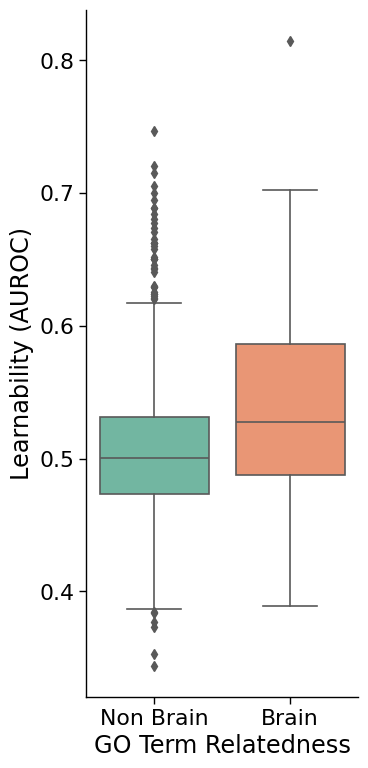

In [12]:
def plot(merged)->None:
    sns.set_context("paper", font_scale=1.8)  # Slightly larger text for clarity
    plt.figure(figsize=(4, 8))  # Adjust figure size    

    #  Calc mean for graphing convenience and reduce overplotting
    merged_agg = merged.groupby(['index', 'meta'])['auc'].mean().reset_index()
    merged_agg['meta'] = pd.Categorical(merged_agg.loc[:,'meta'], categories=['Non Brain', 'Brain'], ordered=True)

    # Set the color palette

    set2_colors = sns.color_palette("Set2")
    custom_palette = {
        "Non Brain": set2_colors[0],
        "Brain": set2_colors[1]
        # "PBMC": set2_colors[2]
    }    
    sns.boxplot(merged_agg, x = 'meta', y = 'auc', palette=custom_palette)
    plt.xticks([0,1], ['Non Brain','Brain'])
    plt.ylabel("Learnability (AUROC)")
    plt.xlabel("GO Term Relatedness")


    plt.tight_layout()
    sns.despine()

    # Save the plot
    plt.savefig('figs/brain_GO_learnability.png', dpi = 300,bbox_inches='tight')
    plt.savefig('figs/brain_GO_learnability.svg', dpi = 300,bbox_inches='tight')

plot(merged)

### Evaluate Differences

In [14]:
def fit_mixedlm(merged:pd.DataFrame)->None:
	merged['meta'] = pd.Categorical(merged.loc[:,'meta'], categories=['Non Brain', 'Brain'], ordered=True)
	model = mixedlm("auc ~ meta", merged, groups=merged["id"])
	result = model.fit()
	return result
	
	
result = fit_mixedlm(merged)
result.summary()

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: auc        
No. Observations: 139600  Method:             REML       
No. Groups:       1396    Scale:              0.0012     
Min. group size:  100     Log-Likelihood:     265590.5794
Max. group size:  100     Converged:          Yes        
Mean group size:  100.0                                  
---------------------------------------------------------
               Coef. Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      0.506    0.001 347.963 0.000  0.503  0.509
meta[T.Brain]  0.032    0.005   5.970 0.000  0.022  0.043
Group Var      0.003    0.003                            
=========================================================

"""

In [7]:
result.pvalues

Intercept         0.000000e+00
meta[T.Brain]     2.371790e-09
Group Var        9.576043e-151
dtype: float64

In [8]:
# def plot(merged)->None:

#     #  Calc mean for graphing convenience and reduce overplotting
#     merged_agg = merged.groupby(['index', 'meta'])['auc'].mean().reset_index()
#     merged_agg['meta'] = pd.Categorical(GO_learnabilty_df_mean.loc[:,'meta'], categories=['Neither', 'Brain'], ordered=True)

#     # Set the color palette
#     sns.set_palette('Set2')  # Set the color palette to Dark

#     # Create a FacetGrid with seaborn

#     # Draw a boxplot in each facet
#     g.map(sns.boxplot, 'exp_type', 'auc', 'meta', palette="Set2")

#     # Set the background color to white
#     plt.gca().set_facecolor('white')

#     # Remove facet titles
#     g.set_titles("")

#     # Set x-axis labels with smaller font size separately for each column
#     g.axes[0, 0].set_xlabel('Brain', fontsize=20)
#     g.axes[0, 1].set_xlabel('PBMC', fontsize=20)

#     # Set y-axis label with smaller font size
#     g.set_ylabels("Performance (AUROC)", fontsize=20)

#     # Add a legend with a custom title and font size
#     legend = plt.legend(title="GO Term Category", fontsize=14, bbox_to_anchor=(-0.5,1))

#     # Set the font size of the legend title
#     legend.get_title().set_fontsize(14)

#     # Rename the legend labels
#     legend.get_texts()[0].set_text("Neither")
#     legend.get_texts()[1].set_text("Brain")
#     legend.get_texts()[2].set_text("PBMC")

#     # Access each axis and set custom tick labels
#     for ax in g.axes.flat:
#         ax.set_xticklabels(["Permuted", "Simulated"], fontsize=16)
#         ax.tick_params(axis='y', labelsize=16) 
#     # Adjust the layout to make room for the title
#     g.fig.subplots_adjust(top=0.9)

#     # Add a title to the entire plot
#     # g.fig.suptitle('Simulated Bulk from Cell Type Profiles', fontsize=16)
#     # Add a title to the entire plot
#     # g.fig.suptitle('       Composition Variance Increases \n       Performance of Cell Type Related GO Terms', fontsize=20,  y=1.025)


#     # Save the plot
#     g.savefig('figs/CTProfileBulkResults.png', dpi = 300)